<a href="https://colab.research.google.com/github/amitshara/Google-Playstore-Project/blob/main/04.Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/Play Store Data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [4]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
#Missing Value handling
df = df.dropna()

In [6]:
#Duplicate Value Handling
df = df.drop_duplicates()

In [7]:
# Copy dataframe
df_filtered = df.copy()

In [8]:
# Reviews > 500
df_filtered['Reviews'] = pd.to_numeric(df_filtered['Reviews'], errors='coerce')
df_filtered = df_filtered[df_filtered['Reviews'] > 500]

In [10]:
# Remove apps starting with X, Y, Z
df_filtered = df_filtered[
    ~df_filtered['App'].str.upper().str.startswith(('X', 'Y', 'Z'), na=False)
]

In [11]:
# Remove apps containing letter S
df_filtered = df_filtered[
    ~df_filtered['App'].str.contains('S', case=False, na=False)
]


In [12]:
# Category starts with E, C, or B
df_filtered = df_filtered[
    df_filtered['Category'].str.startswith(('E', 'C', 'B'), na=False)
]

In [13]:
#Translate Catogery
category_translation = {
    'BEAUTY': 'सौंदर्य',      # Hindi
    'BUSINESS': 'வணிகம்',    # Tamil
    'DATING': 'Dating'       # Temporary
}

df_filtered['Category'] = df_filtered['Category'].replace(category_translation)

# German translation
df_filtered['Category'] = df_filtered['Category'].replace({
    'Dating': 'Partnersuche'
})

In [14]:
#Clean Data Column
df_filtered['Last Updated'] = pd.to_datetime(
    df_filtered['Last Updated'],
    errors='coerce'
)

df_filtered = df_filtered.dropna(subset=['Last Updated'])

In [15]:
#Clean Install
df_filtered['Installs'] = (
    df_filtered['Installs']
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)

df_filtered['Installs'] = pd.to_numeric(
    df_filtered['Installs'],
    errors='coerce'
)

df_filtered = df_filtered.dropna(subset=['Installs'])

In [17]:
#Aggregate Monthly Installs by Category
df_filtered['Month'] = (
    df_filtered['Last Updated']
    .dt.to_period('M')
    .dt.to_timestamp()
)

monthly_installs = (
    df_filtered
    .groupby(['Month', 'Category'])['Installs']
    .sum()
    .reset_index()
)

In [18]:
#Calculating MoM growth
monthly_installs['MoM_Growth'] = (
    monthly_installs
    .groupby('Category')['Installs']
    .pct_change()
)

In [19]:
#Dashboard Time Restriction
from datetime import datetime
import pytz

ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

if not (18 <= current_time.hour < 21):
    print("Graph available only between 6 PM IST and 9 PM IST")
else:
    print("Render graph")

Graph available only between 6 PM IST and 9 PM IST


/tmp/ipykernel_2270/1248904176.py:38: UserWarning: Glyph 2997 (\N{TAMIL LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2270/1248904176.py:38: UserWarning: Matplotlib currently does not support Tamil natively.
  plt.tight_layout()
/tmp/ipykernel_2270/1248904176.py:38: UserWarning: Glyph 2979 (\N{TAMIL LETTER NNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2270/1248904176.py:38: UserWarning: Glyph 3007 (\N{TAMIL VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2270/1248904176.py:38: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2270/1248904176.py:38: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2270/1248904176.py:38: UserWarning: Glyph 3021 (\N{TAMIL SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2270/1248904176.py:

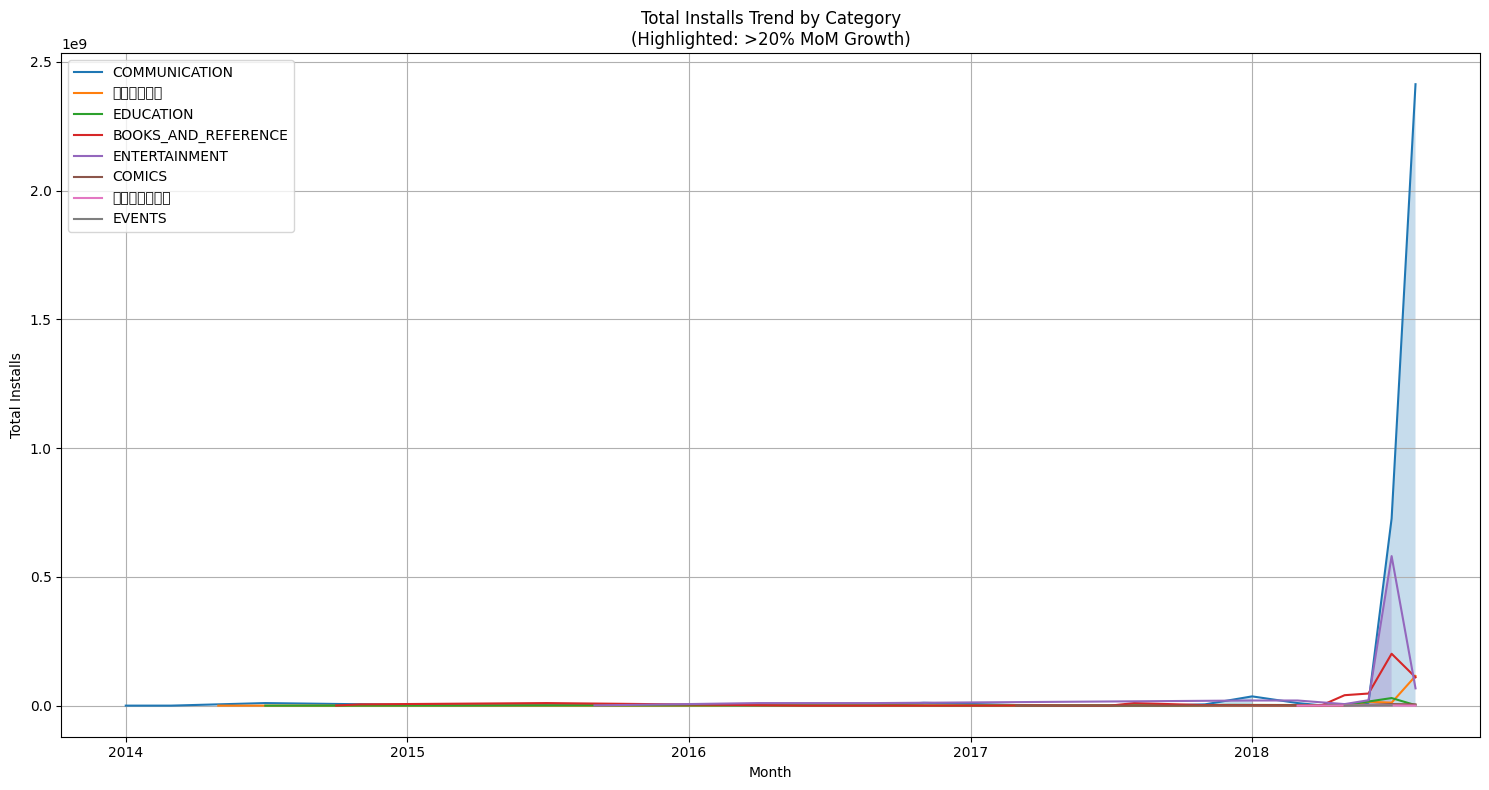

In [21]:
#Plot Time Series with Growth Highlighting
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for category in monthly_installs['Category'].unique():

    cat_data = (
        monthly_installs[
            monthly_installs['Category'] == category
        ]
        .sort_values('Month')
    )

    plt.plot(
        cat_data['Month'],
        cat_data['Installs'],
        label=category
    )

    growth_mask = cat_data['MoM_Growth'] > 0.20

    plt.fill_between(
        cat_data['Month'],
        cat_data['Installs'],
        where=growth_mask,
        alpha=0.25
    )

plt.title(
    'Total Installs Trend by Category\n(Highlighted: >20% MoM Growth)'
)

plt.xlabel('Month')
plt.ylabel('Total Installs')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()